# Sistema de Scoring Crediticio con Optimización de Rentabilidad Ajustada por Riesgo

## Objetivos del análisis exploratorio

Una vez construido el conjunto de datos bajo una estrategia orientada a evitar *data leakage* y conservar únicamente la información disponible en el momento de la solicitud del crédito, el siguiente paso consiste en comprender en profundidad el comportamiento de las variables que describen a los solicitantes y su relación con el riesgo de incumplimiento.

El propósito del Análisis Exploratorio de Datos (EDA) no es únicamente describir el conjunto de datos, sino generar evidencia que permita tomar decisiones fundamentadas para las etapas posteriores de preprocesamiento, ingeniería de variables y modelado predictivo. En el contexto de un sistema de *credit scoring*, estas decisiones deben preservar tanto el desempeño predictivo como la interpretabilidad del modelo, requisito indispensable para aplicaciones financieras.

En esta etapa se buscará responder, entre otras, las siguientes preguntas:

- ¿Cuál es el nivel de desbalance entre clientes cumplidos e incumplidos?
- ¿Qué características financieras presentan los prestatarios con mayor riesgo de impago?
- ¿Existen variables con distribuciones altamente asimétricas o valores extremos que requieran tratamiento?
- ¿Los valores faltantes representan ausencia de información o contienen información relevante sobre el riesgo del cliente?
- ¿Existen categorías con muy pocas observaciones que deban agruparse para mejorar la estabilidad del modelo?
- ¿Qué variables presentan una mayor capacidad para discriminar entre buenos y malos pagadores?
- ¿Existen relaciones de alta correlación que puedan generar redundancia o problemas de multicolinealidad?

A diferencia de un análisis exploratorio tradicional, este EDA se desarrolla con un enfoque específico para modelos de riesgo crediticio. Por esta razón, todas las decisiones de análisis se realizan únicamente sobre el conjunto de entrenamiento obtenido mediante una partición cronológica (*out-of-time split*), garantizando que la información del conjunto de prueba permanezca completamente aislada hasta la evaluación final del modelo.

Como resultado de esta fase se definirán los criterios que guiarán el resto del pipeline de modelado, entre ellos:

- estrategia de imputación para cada tipo de valor faltante;
- tratamiento de valores extremos;
- agrupación de categorías poco frecuentes;
- discretización de variables continuas cuando mejore la interpretabilidad del modelo;
- selección inicial de variables basada en evidencia estadística y conocimiento de negocio;
- identificación de variables redundantes antes del entrenamiento de los modelos de clasificación.

De esta manera, el EDA constituye el puente entre la limpieza inicial del conjunto de datos y la construcción de un sistema de *credit scoring* capaz de segmentar clientes según su nivel de riesgo y servir como base para la optimización de políticas de aprobación y rentabilidad del portafolio.

## 2.0 Librerías y funciones

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

from src.visualization import *

print(COLORS)

c:\Users\camil\Documents\GitHub\lendingclub-credit-risk-ml


In [2]:
pd.read_parquet(r"../data/processed/df_semiclean.parquet")

,fico_range_low,revol_util,open_acc,verification_status,il_util,open_il_12m,installment,tot_cur_bal,inq_last_6mths,dti,...,open_rv_12m_missing,max_bal_bc_missing,open_il_12m_missing,total_bal_il_missing,open_rv_24m_missing,open_il_24m_missing,tot_cur_bal_missing,tot_coll_amt_missing,emp_length_num,target
0,675.0,29.7,7.0,Not Verified,36.0,0.0,123.03,144904.0,1.0,5.91,...,0,0,0,0,0,0,0,0,10,1
1,715.0,19.2,22.0,Not Verified,73.0,0.0,820.28,204396.0,4.0,16.06,...,0,0,0,0,0,0,0,0,10,1
2,695.0,56.2,6.0,Not Verified,73.0,0.0,432.66,189699.0,0.0,10.78,...,0,0,0,0,0,0,0,0,10,1
3,695.0,64.5,12.0,Source Verified,84.0,0.0,289.91,331730.0,3.0,25.37,...,0,0,0,0,0,0,0,0,3,1
4,690.0,68.4,5.0,Source Verified,99.0,0.0,405.18,12798.0,0.0,10.20,...,0,0,0,0,0,0,0,0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344796,735.0,34.0,17.0,Not Verified,52.0,0.0,377.95,168758.0,1.0,20.59,...,0,0,0,0,0,0,0,0,5,1
1344797,705.0,85.2,16.0,Not Verified,50.0,2.0,683.94,663465.0,1.0,22.03,...,0,0,0,0,0,0,0,0,9,1
1344798,735.0,27.4,14.0,Source Verified,47.0,0.0,752.74,408701.0,0.0,10.34,...,0,0,0,0,0,0,0,0,3,0
1344799,665.0,55.0,12.0,Not Verified,79.0,2.0,362.34,65797.0,0.0,12.25,...,0,0,0,0,0,0,0,0,10,1


In [3]:
df = pd.read_parquet(r"../data/processed/df_semiclean.parquet")

In [4]:
df.columns

Index(['fico_range_low', 'revol_util', 'open_acc', 'verification_status',
       'il_util', 'open_il_12m', 'installment', 'tot_cur_bal',
       'inq_last_6mths', 'dti', 'total_cu_tl', 'inq_fi', 'initial_list_status',
       'acc_now_delinq', 'annual_inc', 'inq_last_12m', 'mths_since_rcnt_il',
       'pub_rec', 'addr_state', 'total_bal_il', 'issue_d', 'open_rv_12m',
       'int_rate', 'delinq_2yrs', 'revol_bal', 'earliest_cr_line', 'sub_grade',
       'open_rv_24m', 'all_util', 'mths_since_last_delinq', 'home_ownership',
       'collections_12_mths_ex_med', 'fico_range_high', 'emp_length',
       'loan_status', 'loan_amnt', 'open_il_24m', 'policy_code', 'open_acc_6m',
       'max_bal_bc', 'application_type', 'tot_coll_amt', 'funded_amnt',
       'grade', 'term', 'purpose', 'total_acc', 'issue_year',
       'il_util_missing', 'mths_since_rcnt_il_missing', 'all_util_missing',
       'total_cu_tl_missing', 'open_acc_6m_missing', 'inq_last_12m_missing',
       'inq_fi_missing', 'open_rv_12m

## 2.1 División temporal del conjunto de datos (Out-of-Time Split)

In [5]:
# ==========================================================
# Dataset preparation
# ==========================================================
df_eda = df.copy()

df_eda = (
    df_eda
    .sort_values("issue_d")
    .reset_index(drop=True)
)

assert df_eda["issue_d"].is_monotonic_increasing, \
    "The dataset is not ordered chronologically."

# ==========================================================
# Out-of-Time Split (80% Train - 20% Test)
# ==========================================================

split_idx = int(len(df_eda) * 0.80)

train = df_eda.iloc[:split_idx].copy()
test = df_eda.iloc[split_idx:].copy()

train["dataset"] = "Train"
test["dataset"] = "Test"

In [6]:
# ==========================================================
# Split validation
# ==========================================================

print("=" * 70)
print("TRAIN SET")
print(f"Observations : {train.shape[0]:,}")
print(f"Variables    : {train.shape[1]}")
print(f"Period       : {train['issue_d'].min().date()} → {train['issue_d'].max().date()}")

print("\n" + "=" * 70)

print("TEST SET")
print(f"Observations : {test.shape[0]:,}")
print(f"Variables    : {test.shape[1]}")
print(f"Period       : {test['issue_d'].min().date()} → {test['issue_d'].max().date()}")

print("\n" + "=" * 70)

assert train["issue_d"].max() <= test["issue_d"].min(), \
    "Temporal leakage detected."

print("Out-of-Time Split successfully validated.")

TRAIN SET
Observations : 1,075,840
Variables    : 66
Period       : 2007-08-01 → 2016-10-01

TEST SET
Observations : 268,961
Variables    : 66
Period       : 2016-10-01 → 2018-12-01

Out-of-Time Split successfully validated.


In [7]:
# ==========================================================
# Target distribution
# ==========================================================

target_distribution = (
    pd.DataFrame({
        "Train": train["target"].value_counts(normalize=True),
        "Test": test["target"].value_counts(normalize=True)
    })
    .rename(index={
        0: "Good Loan",
        1: "Default"
    })
)

display(
    target_distribution.style.format("{:.2%}")
)

,Train,Test
target,,
Default,80.44%,78.21%
Good Loan,19.56%,21.79%


In [8]:
target_summary = pd.DataFrame({
    "Train Count": train["target"].value_counts(),
    "Train %": train["target"].value_counts(normalize=True),
    "Test Count": test["target"].value_counts(),
    "Test %": test["target"].value_counts(normalize=True),
})

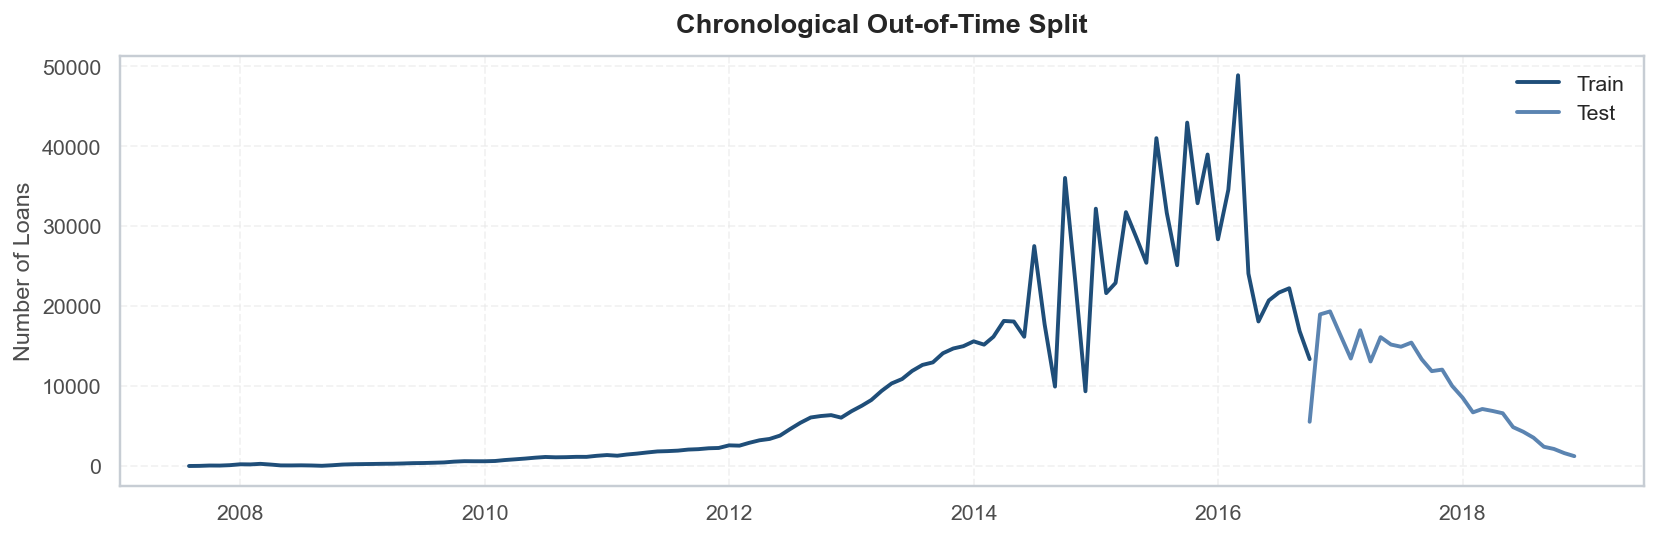

In [9]:
# ==========================================================
# Out-of-Time Split visualization
# ==========================================================

split_plot = (
    pd.concat([train, test])
      .groupby(["issue_d", "dataset"])
      .size()
      .reset_index(name="loans")
)

plt.figure(figsize=(12, 4))

sns.lineplot(
    data=split_plot,
    x="issue_d",
    y="loans",
    hue="dataset",
    linewidth=2
)

plt.title("Chronological Out-of-Time Split", fontsize=14)
plt.xlabel("")
plt.ylabel("Number of Loans")

plt.legend(title="")
plt.tight_layout()

plt.show()

In [10]:
# ==========================================================
# Training Set Characterization
# ==========================================================

# Tipo de variables
numeric_vars = train.select_dtypes(include=["number"]).columns.tolist()
categorical_vars = train.select_dtypes(include=["object", "category"]).columns.tolist()
datetime_vars = train.select_dtypes(include=["datetime"]).columns.tolist()

# Variables con valores faltantes
missing_summary = (
    train.isna()
         .mean()
         .mul(100)
         .round(2)
)

missing_summary = (
    missing_summary[missing_summary > 0]
    .sort_values(ascending=False)
)

# Distribución de la variable objetivo
target_distribution = (
    train["target"]
    .value_counts(normalize=True)
    .rename(index={0: "Bad (Default)", 1: "Good (Paid)"})
    .mul(100)
    .round(2)
)

summary = pd.DataFrame({
    "Metric": [
        "Ovservaciones",
        "Variables",
        "Buenos prestamos",
        "Malos prestamos",
        "Variables numericas",
        "Variables categoricass",
        "Variables de tiempo",
        "Variables con variables faltantes"
    ],
    "Value": [
        f"{train.shape[0]:,}",
        train.shape[1],
        f"{target_distribution['Good (Paid)']:.2f}%",
        f"{target_distribution['Bad (Default)']:.2f}%",
        len(numeric_vars),
        len(categorical_vars),
        len(datetime_vars),
        len(missing_summary)
    ]
})

display(summary)

print("\nVariables with pending missing values:")
display(
    missing_summary.rename("Missing (%)").to_frame()
)

,Metric,Value
0,Ovservaciones,"1,075,840"
1,Variables,66
2,Buenos prestamos,80.44%
3,Malos prestamos,19.56%
4,Variables numericas,53
5,Variables categoricass,11
6,Variables de tiempo,2
7,Variables con variables faltantes,3



Variables with pending missing values:


,Missing (%)
il_util,78.38
mths_since_rcnt_il,75.75
mths_since_last_delinq,50.46


### 2.2.1 Perfil financiero del solicitante

El primer bloque del análisis univariante examina las principales variables que describen la capacidad económica del solicitante y las características financieras iniciales del préstamo.

Se analizan tres variables disponibles al momento de la solicitud del crédito:

- **annual_inc:** ingreso anual declarado por el solicitante.
- **loan_amnt:** monto solicitado del préstamo.
- **installment:** valor de la cuota mensual pactada.

El objetivo es identificar la forma de sus distribuciones, detectar posibles valores extremos y evaluar si los comportamientos observados son consistentes con la naturaleza del negocio antes de definir estrategias de transformación o tratamiento de outliers.

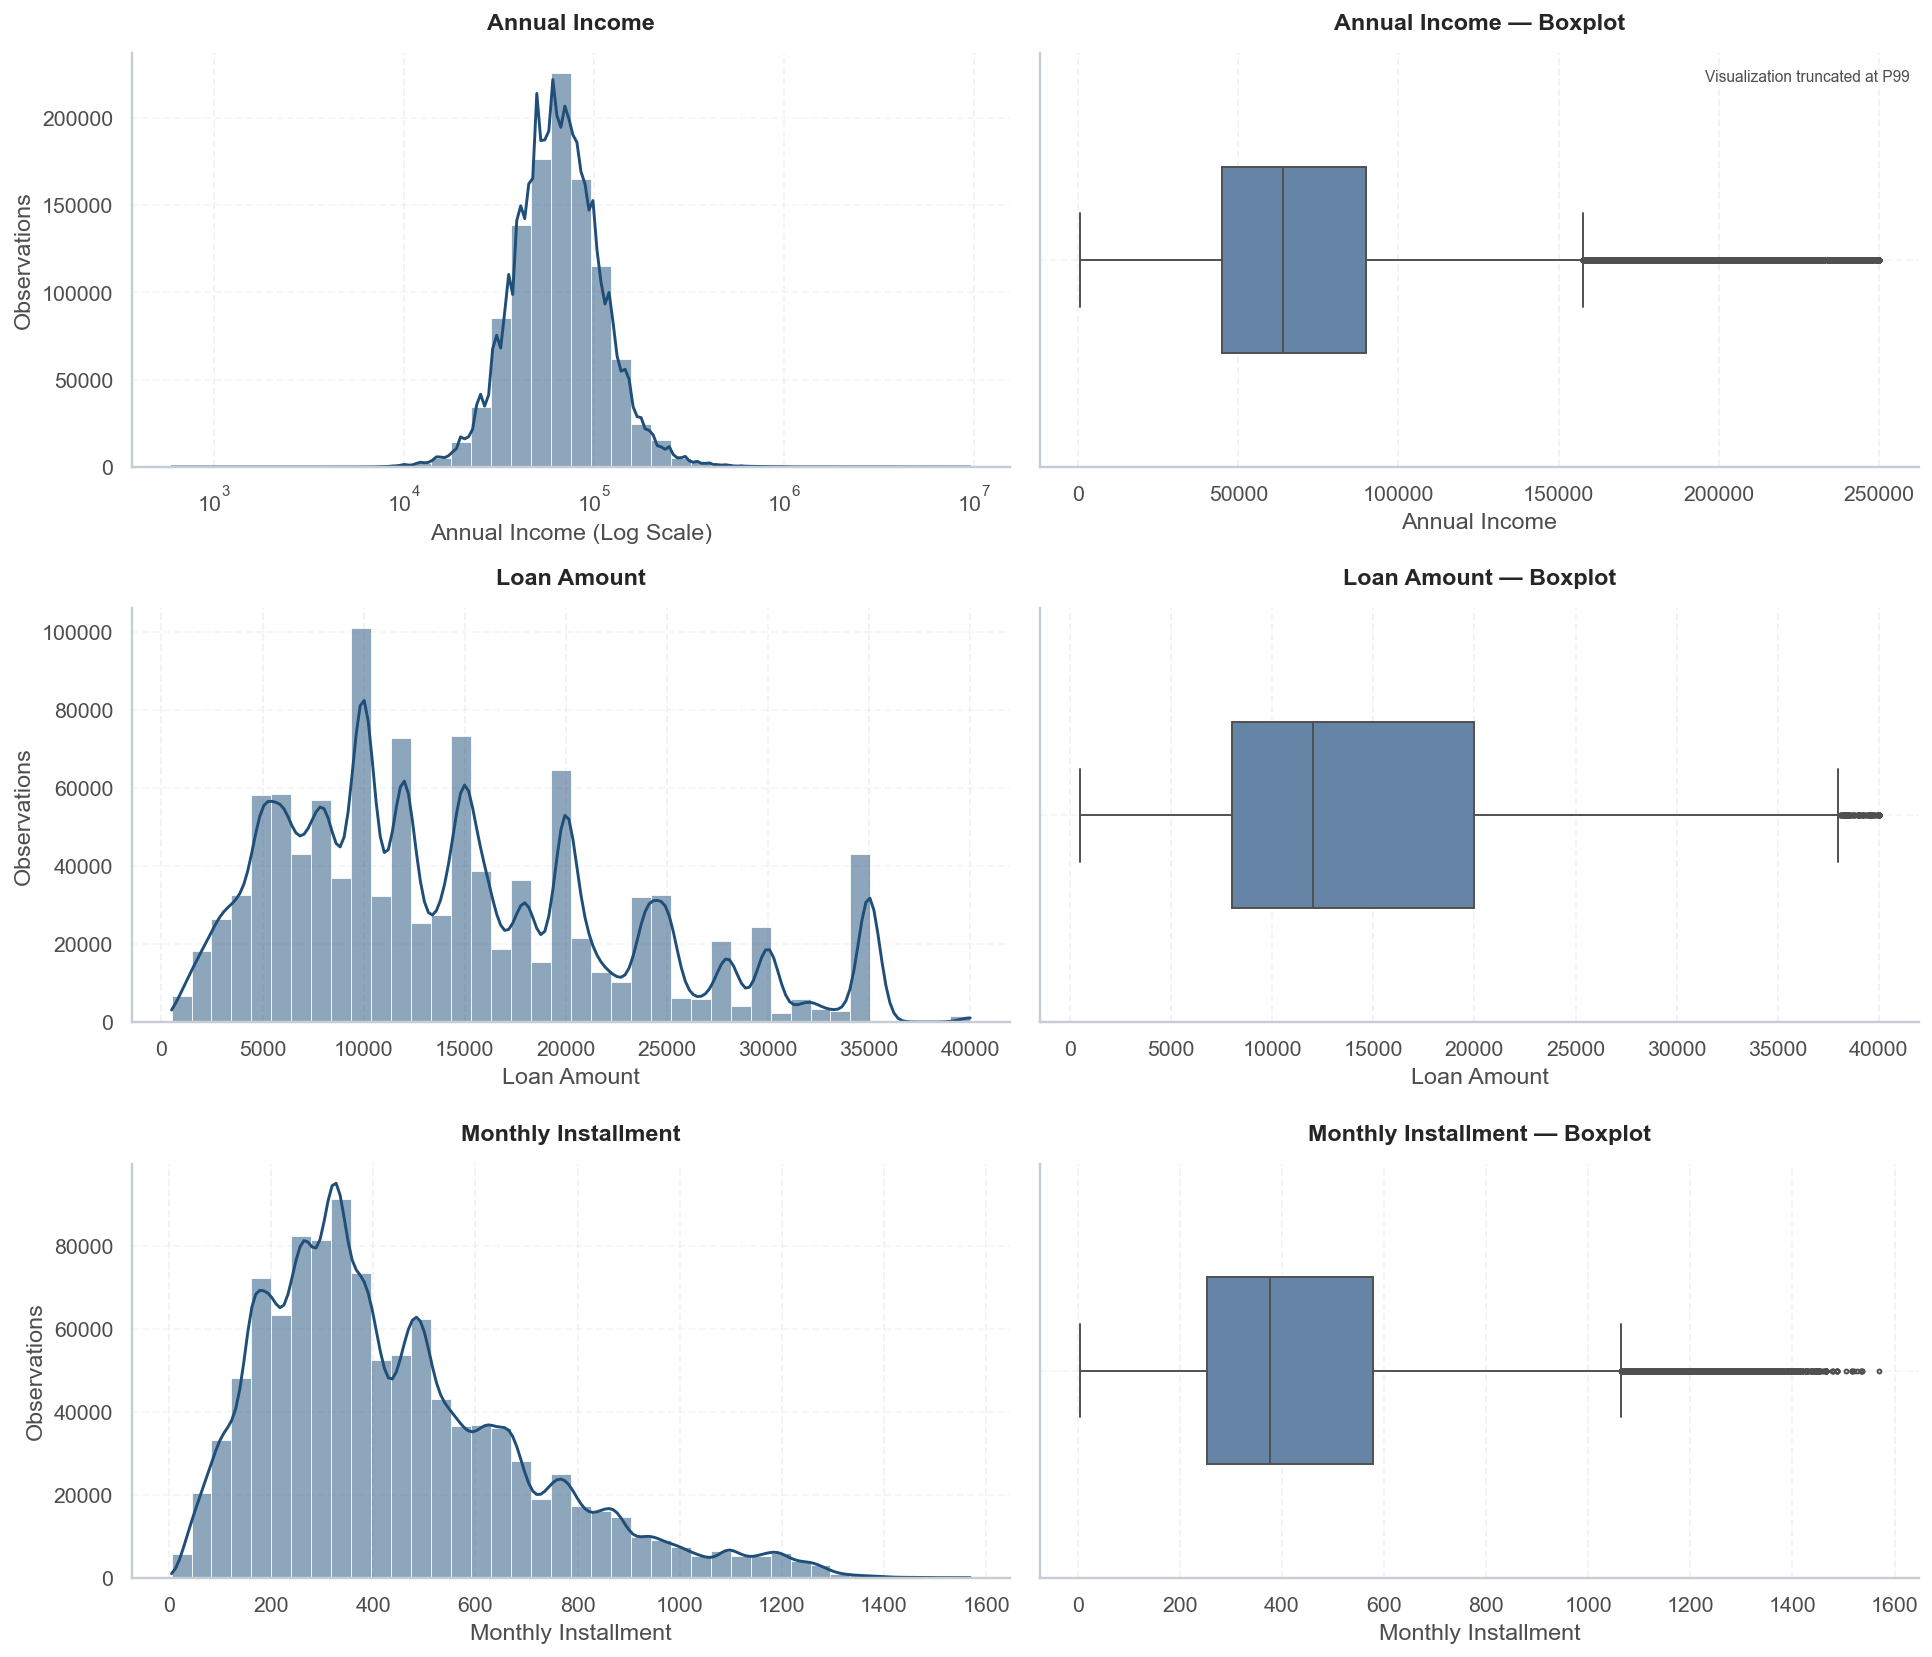

In [11]:
plot_univariate(
    data=train,
    variables=[
        "annual_inc",
        "loan_amnt",
        "installment"
    ],
    titles={
        "annual_inc":"Annual Income",
        "loan_amnt":"Loan Amount",
        "installment":"Monthly Installment"
    },
    log_variables=["annual_inc"],
    truncate_boxplot={
        "annual_inc":0.99
    }
)

### 2.2.2 Perfil de riesgo crediticio

Objetivo

Evaluar si las principales variables relacionadas con el historial y la capacidad crediticia presentan una relación consistente con el riesgo de incumplimiento. A diferencia del apartado anterior, el interés no se centra en describir la distribución de los datos, sino en identificar variables con capacidad discriminatoria que puedan aportar valor al modelo de scoring.

Las variables analizadas corresponden a indicadores ampliamente utilizados por las entidades financieras para evaluar la solvencia de un solicitante:

- dti
- revol_util
- fico_range_low
- fico_range_high

Para cada variable se analizarán dos aspectos:

- Distribución general y presencia de valores extremos mediante diagramas de caja.
- Evolución de la tasa de incumplimiento a lo largo de la variable mediante cuantiles, permitiendo evaluar relaciones monotónicas y posibles puntos de corte útiles para una futura discretización.

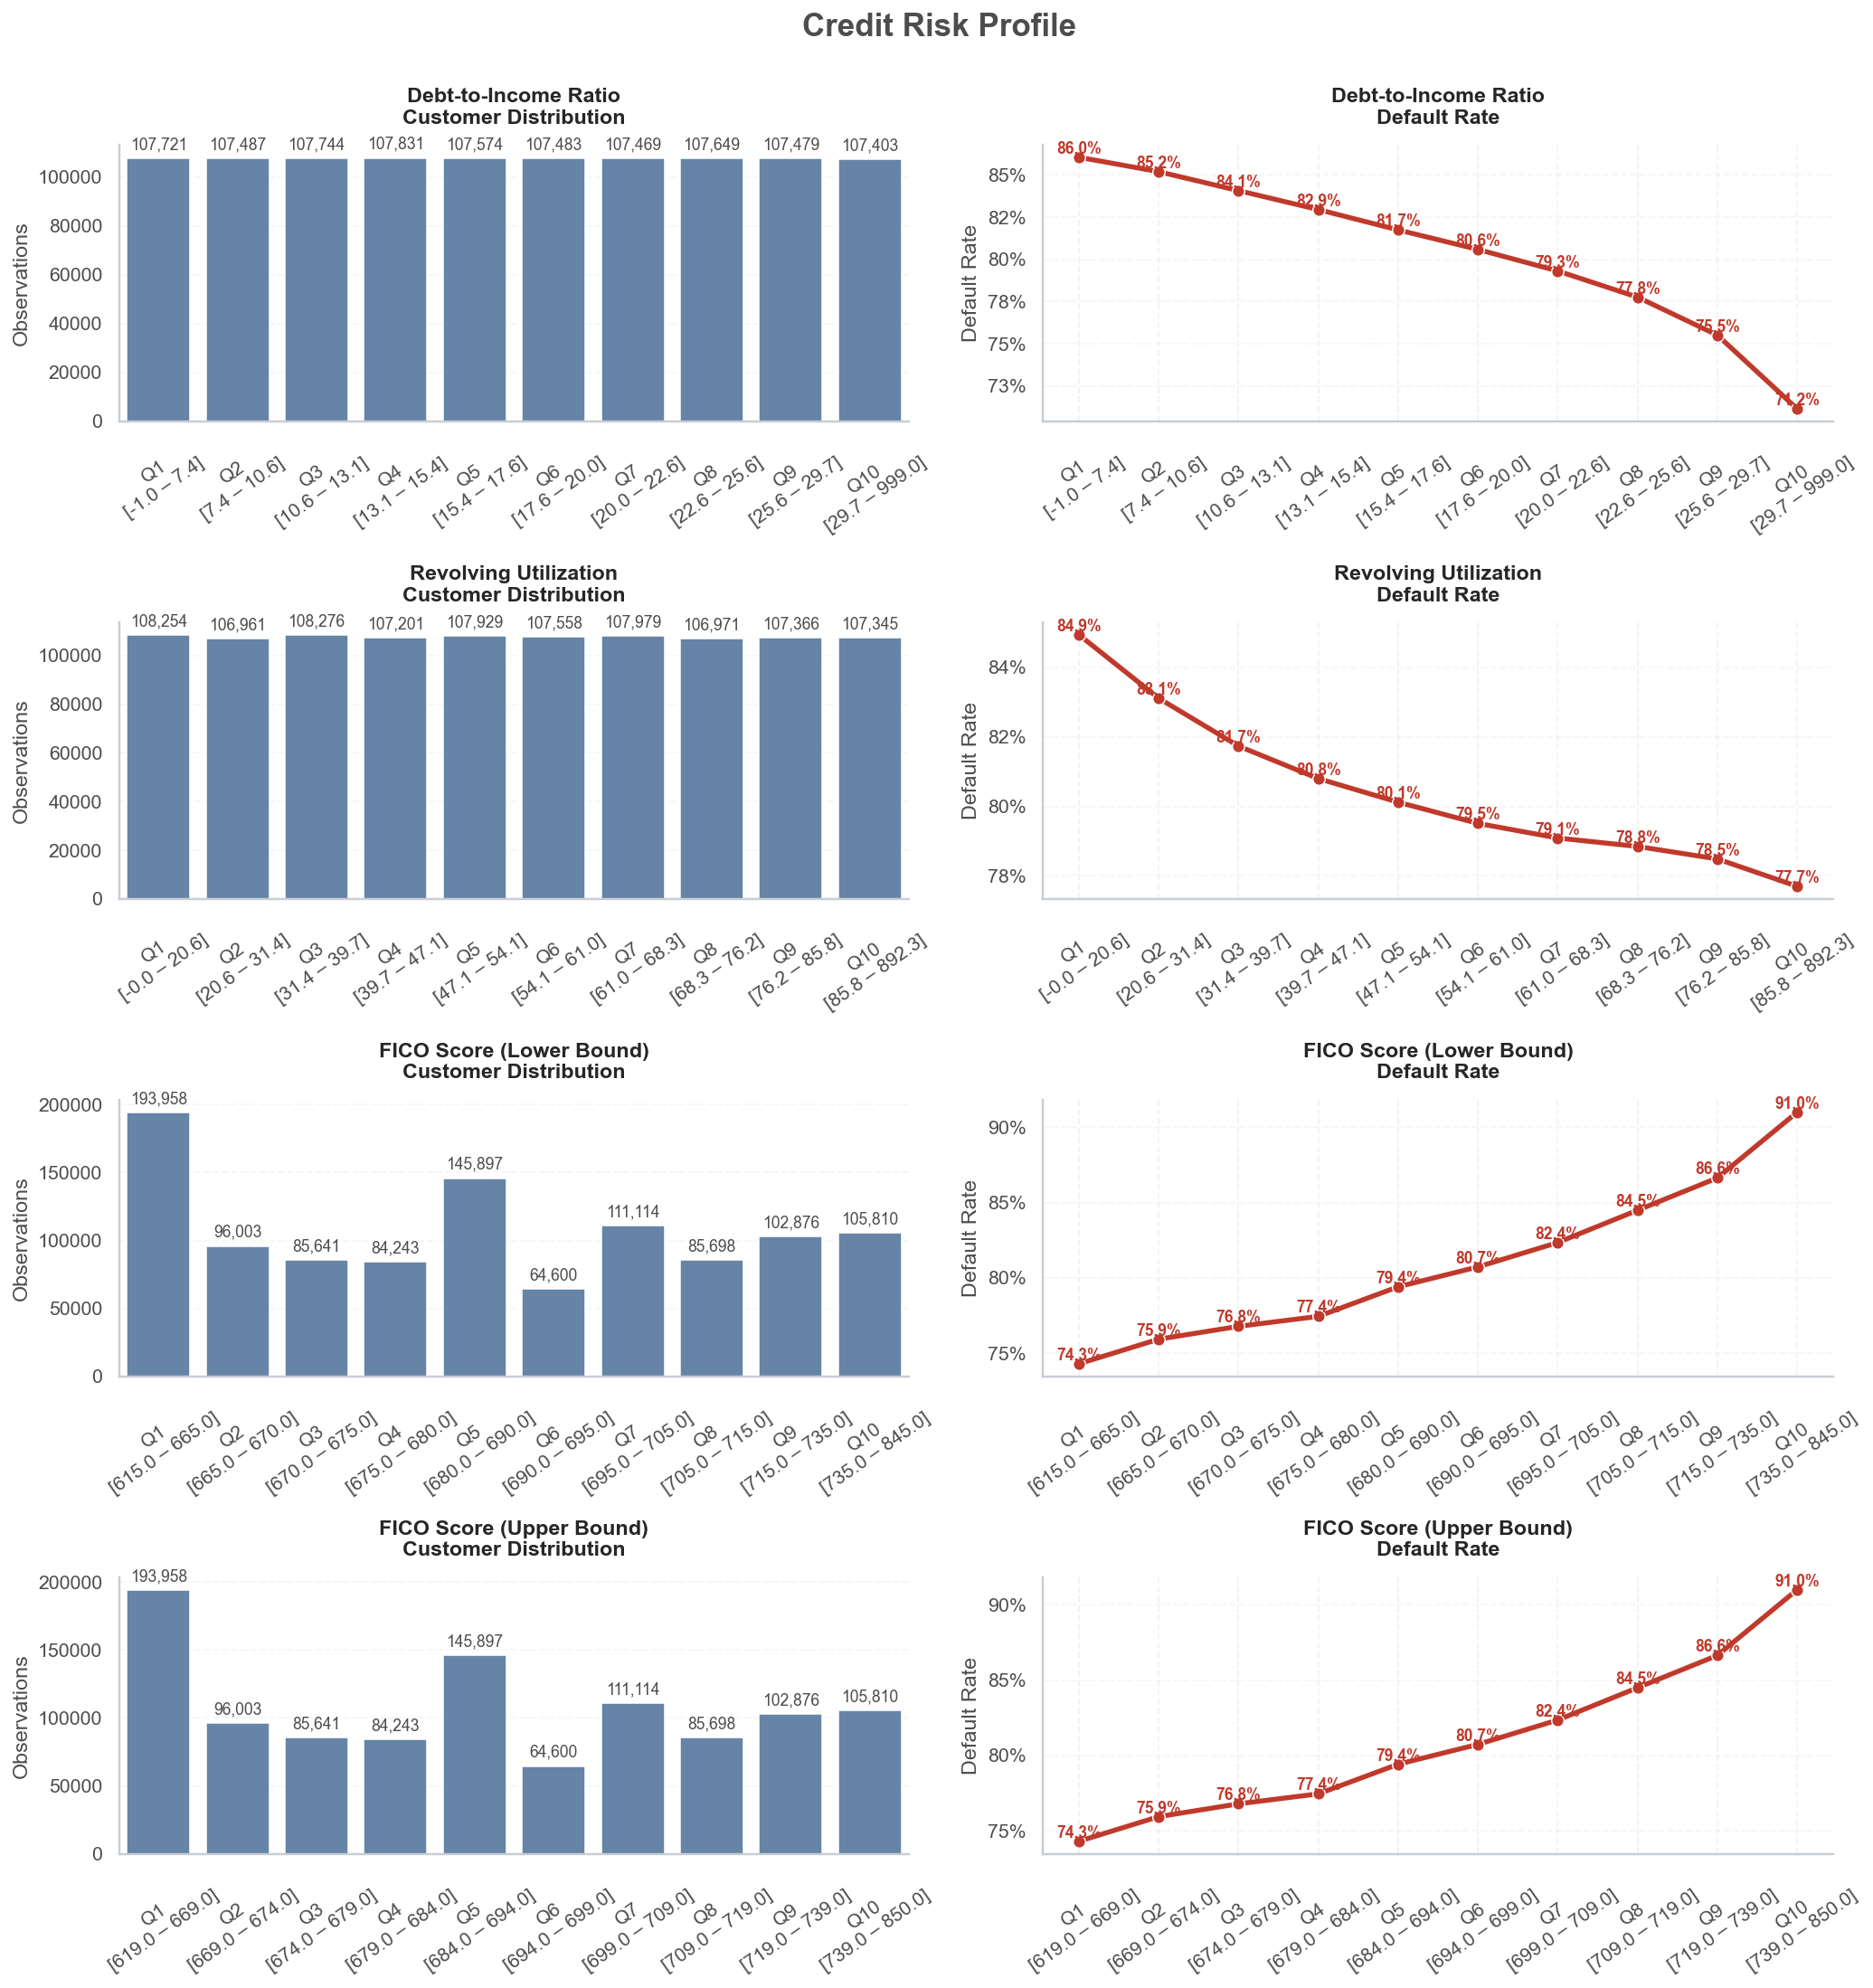

In [12]:
# ==========================================================
# 2.2.2 Credit Risk Profile
# ==========================================================

risk_summary = plot_target_analysis(
    data=train,
    target="target",
    variables=[
        "dti",
        "revol_util",
        "fico_range_low",
        "fico_range_high"
    ],
    titles={
        "dti": "Debt-to-Income Ratio",
        "revol_util": "Revolving Utilization",
        "fico_range_low": "FICO Score (Lower Bound)",
        "fico_range_high": "FICO Score (Upper Bound)"
    },
    section_title="Credit Risk Profile"
)

### 2.3.3 Credit History

Previous credit behavior is one of the strongest predictors of future credit risk. Variables describing past delinquencies, recent credit inquiries and the utilization of revolving credit provide evidence of an applicant's historical payment discipline and financial behavior.

This section evaluates whether these variables effectively discriminate borrowers according to their probability of default. Instead of focusing on their distributions, the analysis examines how the default rate changes across different levels of each predictor.

The objective is to identify variables with strong monotonic relationships that can contribute meaningful predictive power during the modeling stage.

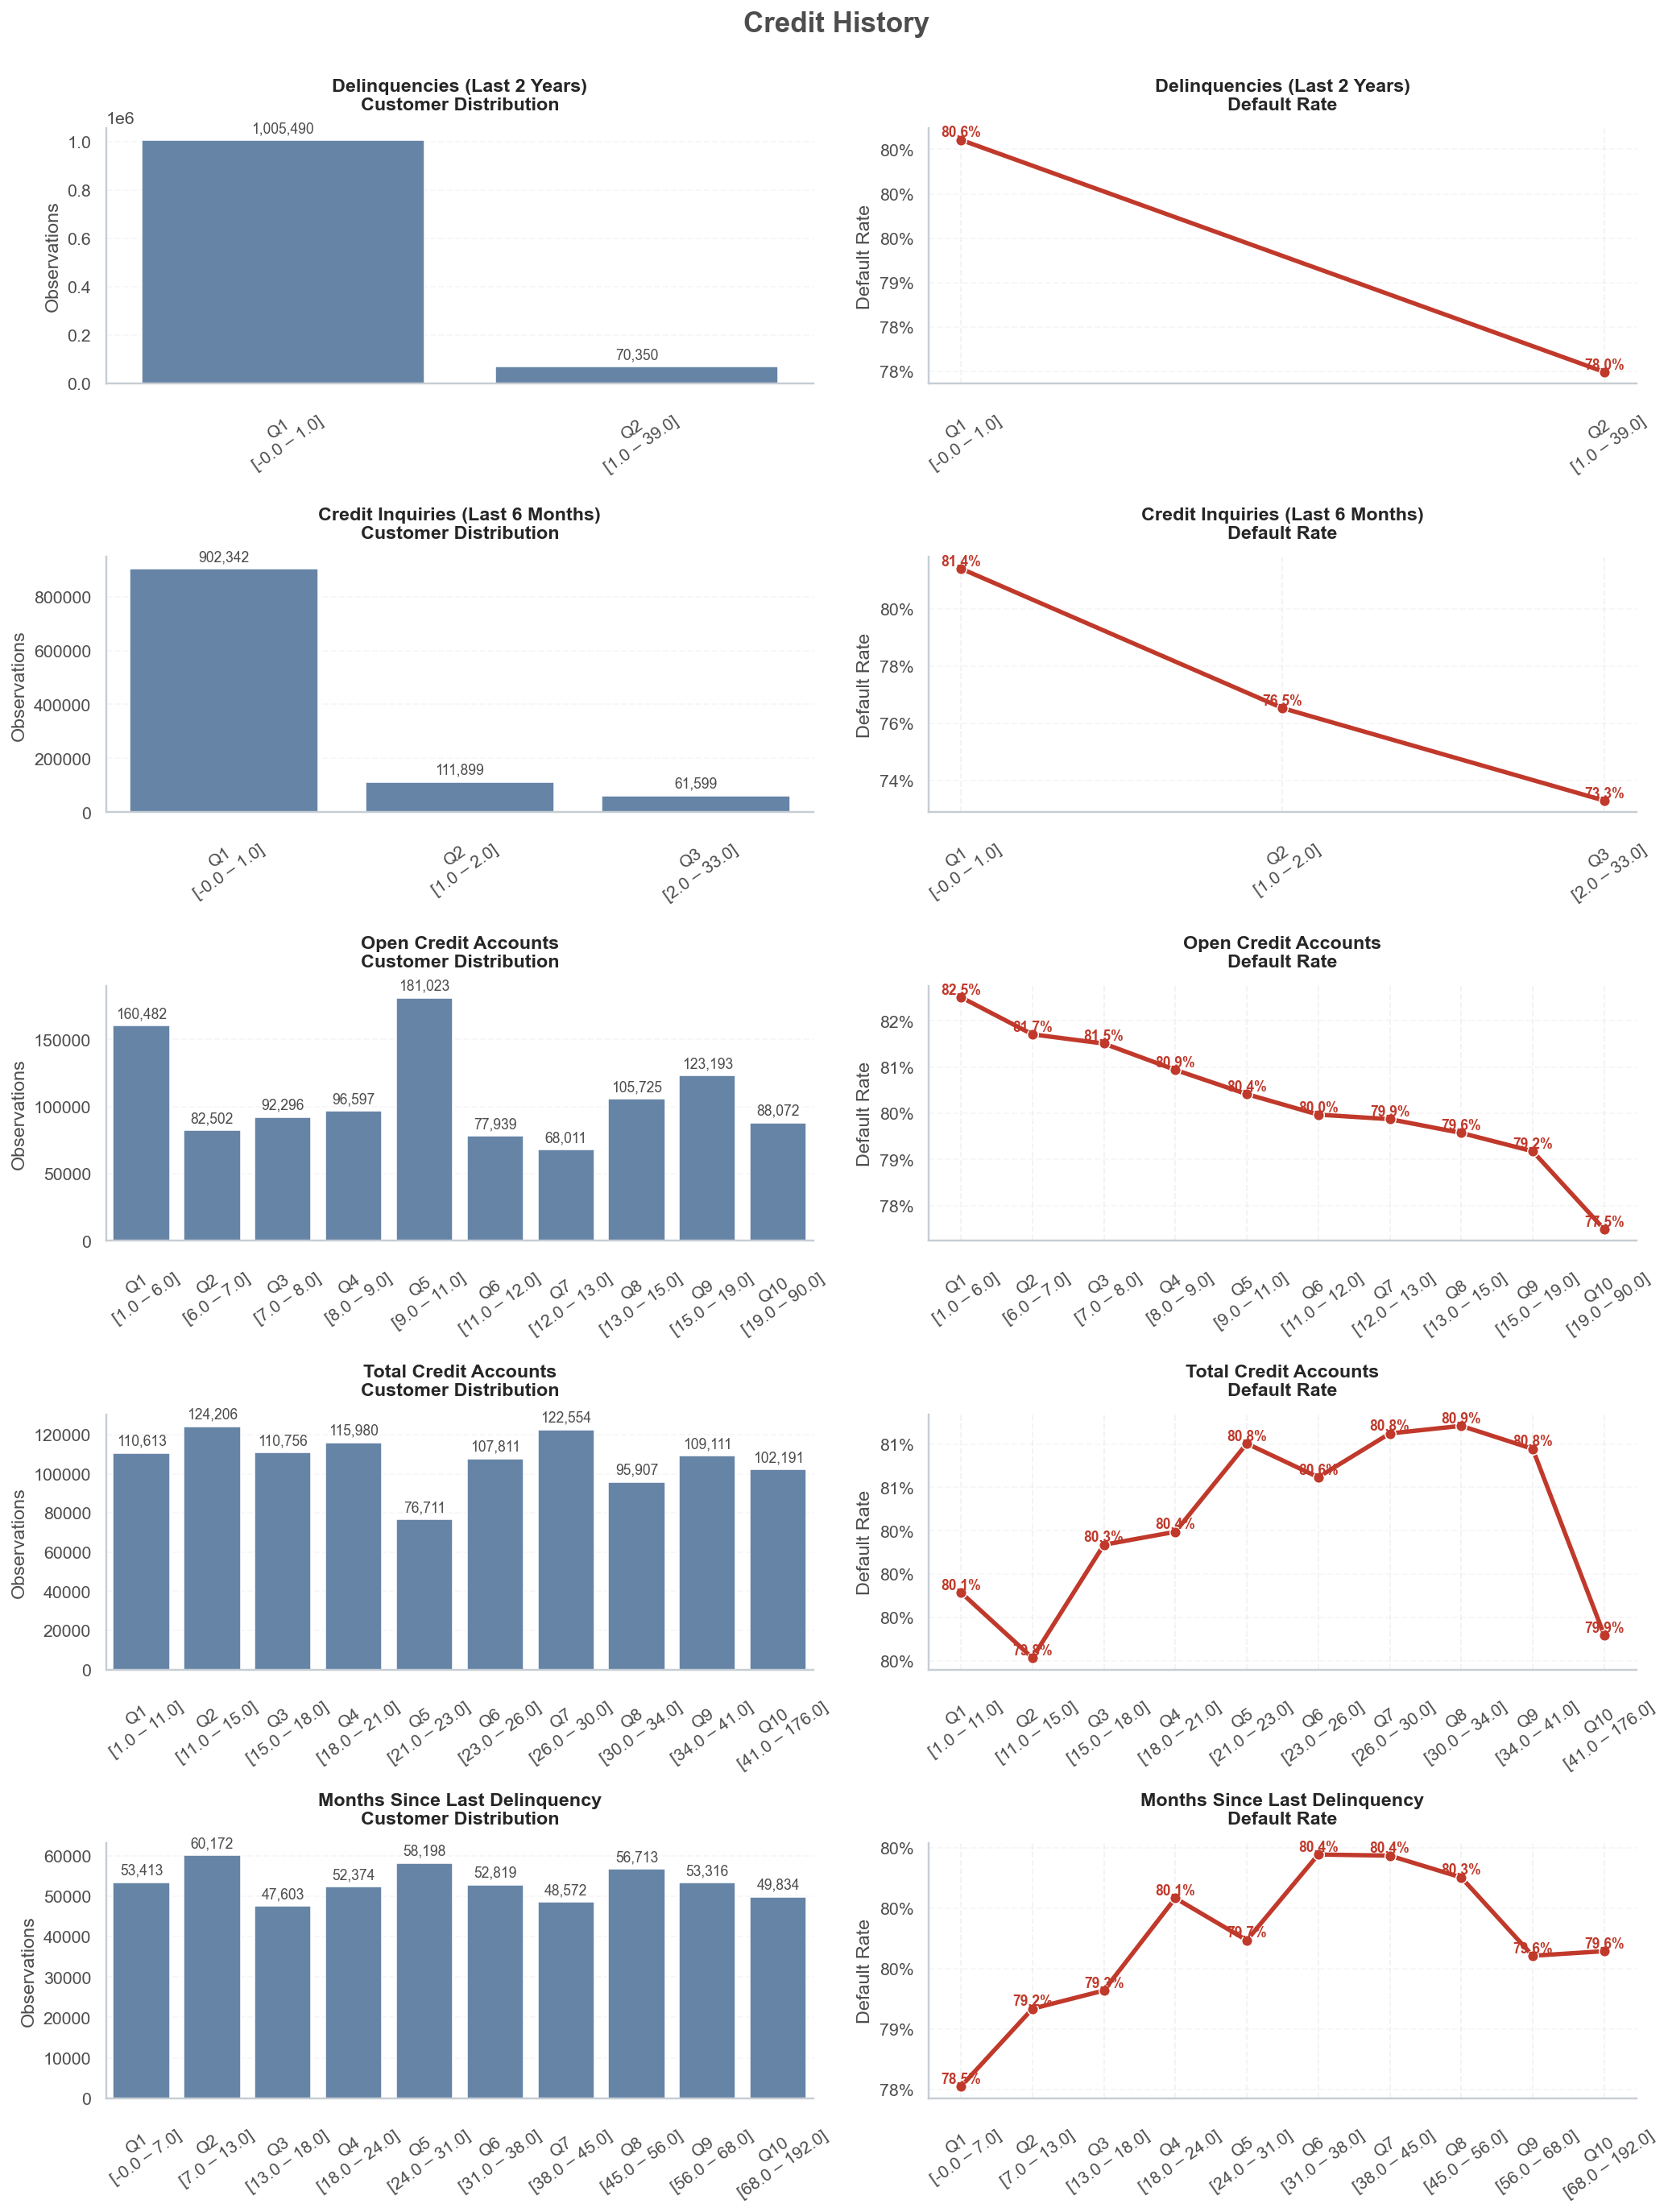

In [13]:
# ==========================================================
# 2.2.3 Credit History
# ==========================================================

history_summary = plot_target_analysis(
    data=train,
    target="target",
    variables=[
        "delinq_2yrs",
        "inq_last_6mths",
        "open_acc",
        "total_acc",
        "mths_since_last_delinq"
    ],
    titles={
        "delinq_2yrs": "Delinquencies (Last 2 Years)",
        "inq_last_6mths": "Credit Inquiries (Last 6 Months)",
        "open_acc": "Open Credit Accounts",
        "total_acc": "Total Credit Accounts",
        "mths_since_last_delinq": "Months Since Last Delinquency"
    },
    section_title="Credit History"
)

In [ ]:
from src.visualization import *

print(COLORS)

NameError: name 'COLORS' is not defined

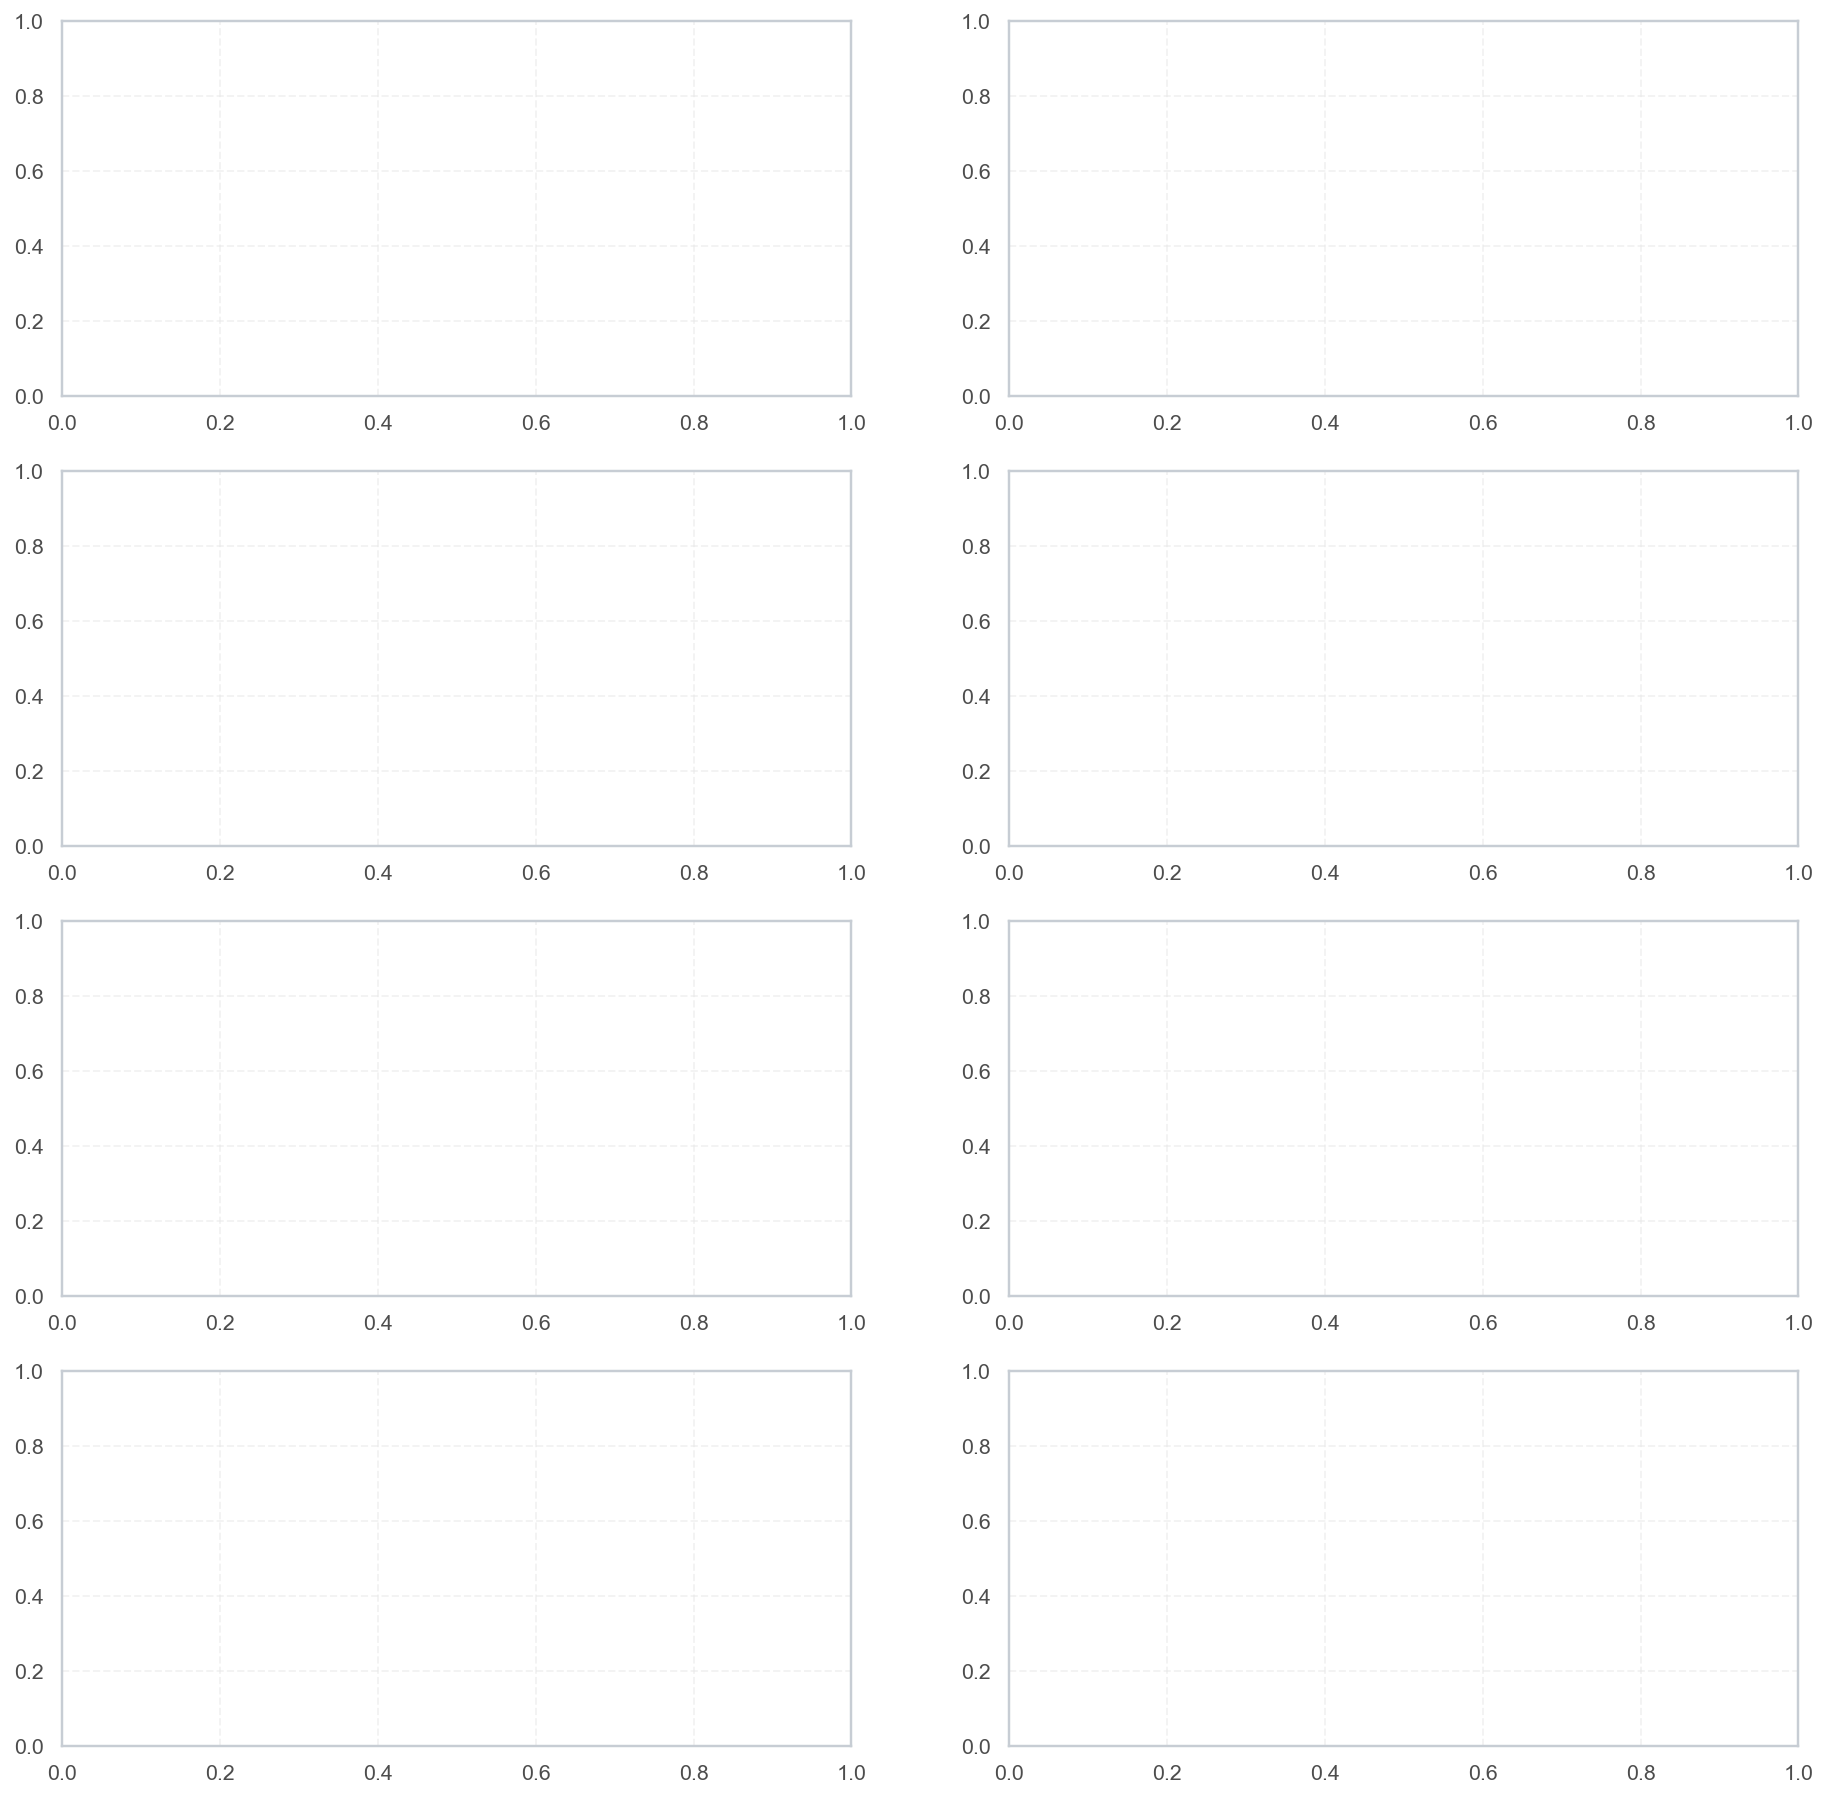

In [15]:
risk_titles = {
    "dti": "Debt-to-Income Ratio",
    "revol_util": "Revolving Credit Utilization",
    "fico_range_low": "FICO Score (Lower Bound)",
    "fico_range_high": "FICO Score (Upper Bound)"
}

risk_profile = plot_risk_profile(
    data=train,
    variables=[
        "dti",
        "revol_util",
        "fico_range_low",
        "fico_range_high"
    ],
    target="target",
    titles=risk_titles,
    bins=10,
    keep_missing=False,
    section_title="Credit Risk Profile"
)

C:\Users\camil\AppData\Local\Temp\ipykernel_15492\3404731749.py:538: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp[var] = temp[var].fillna("Missing")
C:\Users\camil\AppData\Local\Temp\ipykernel_15492\3404731749.py:538: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp[var] = temp[var].fillna("Missing")
C:\Users\camil\AppData\Local\Temp\ipykernel_15492\3404731749.py:538: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in

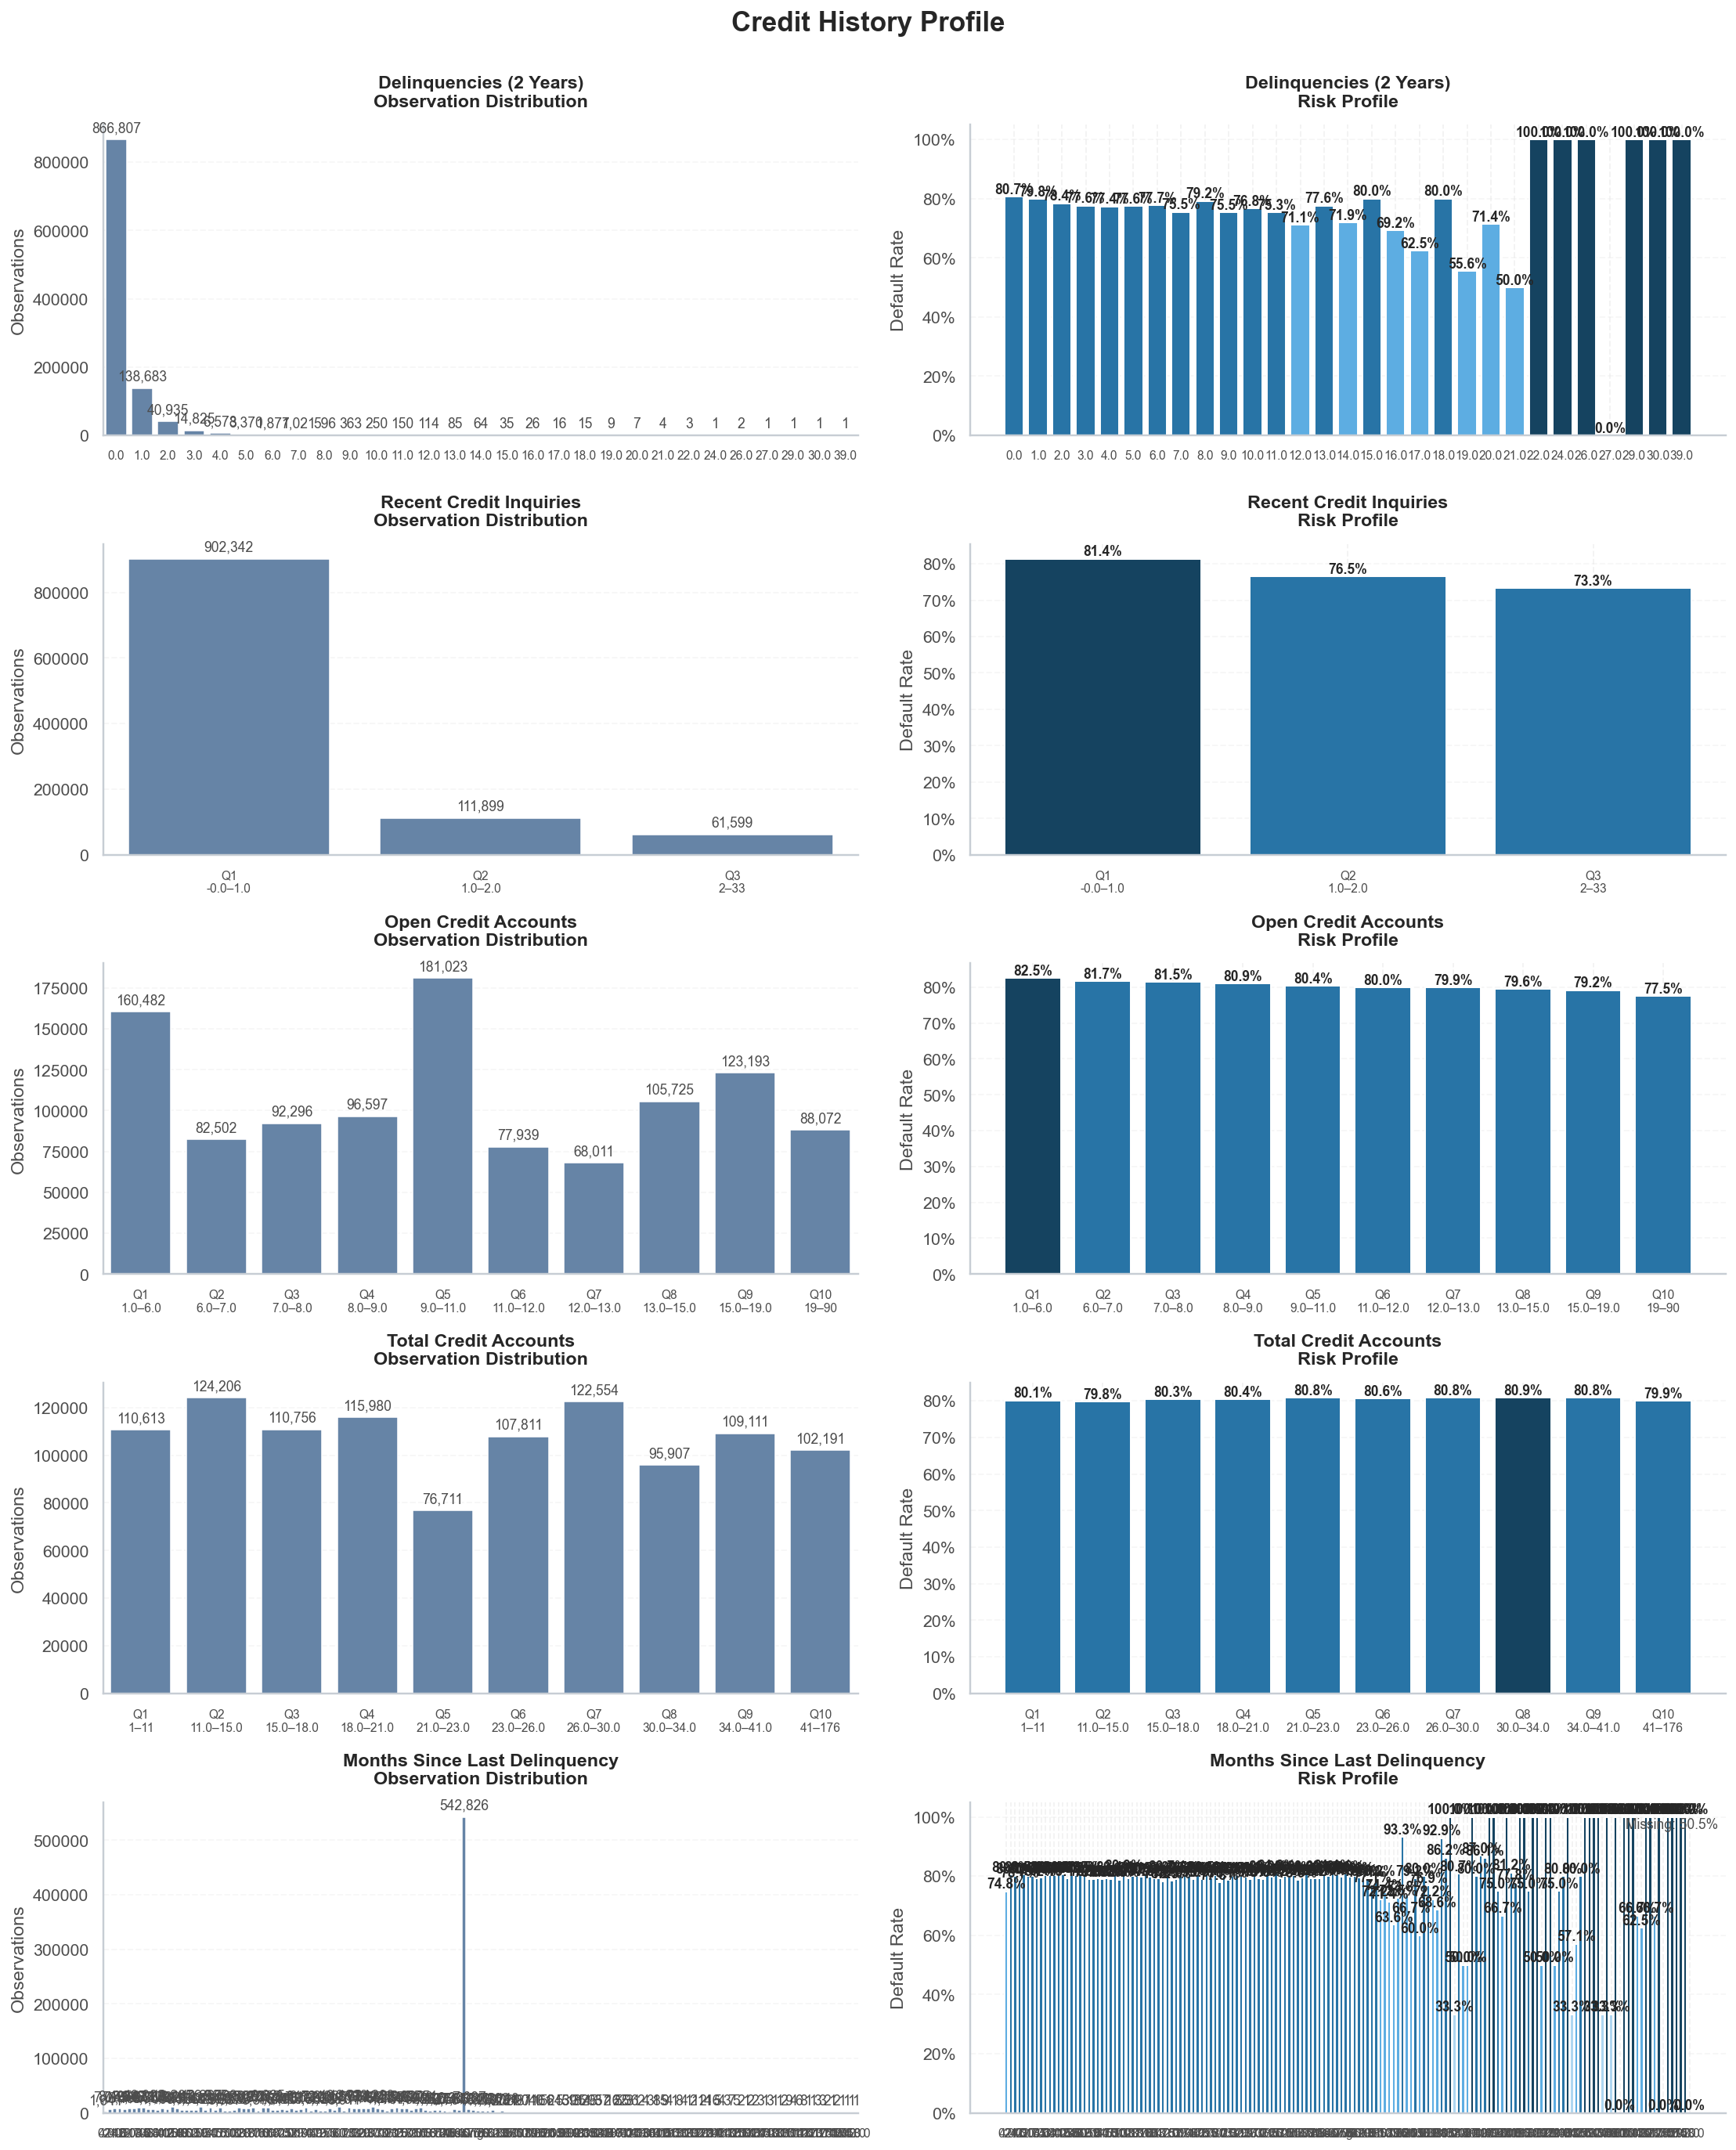

In [ ]:
history_titles = {
    "delinq_2yrs": "Delinquencies (2 Years)",
    "inq_last_6mths": "Recent Credit Inquiries",
    "open_acc": "Open Credit Accounts",
    "total_acc": "Total Credit Accounts",
    "mths_since_last_delinq": "Months Since Last Delinquency"
}

history_profile = plot_risk_profile(
    data=train,
    variables=[
        "delinq_2yrs",
        "inq_last_6mths",
        "open_acc",
        "total_acc",
        "mths_since_last_delinq"
    ],
    target="target",
    titles=history_titles,
    bins=10,
    keep_missing=True,
    detect_zero_inflation=True,
    section_title="Credit History Profile"
)